In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from permit_data_extraction.config import EXTERNAL_DATA_DIR

2025-06-15 20:30:12.809 | INFO     | permit_data_extraction.config:<module>:11 - PROJ_ROOT path is: /home/afhubbard/permit_data_extraction


In [2]:
data_path = Path(f"{EXTERNAL_DATA_DIR}/FRS_FACILITIES.csv")
df = pd.read_csv(data_path)

In [3]:
# Read US states shapefile
states = gpd.read_file(f"{EXTERNAL_DATA_DIR}/us_states/us_states.shp")

In [6]:
contiguous_states = states[~states['STATE'].isin(['Alaska', 'Hawaii', 'Puerto Rico', 'Guam', 'American Samoa', 'United States Virgin Islands', 'Commonwealth of the Northern Mariana Islands'])]


<Axes: >

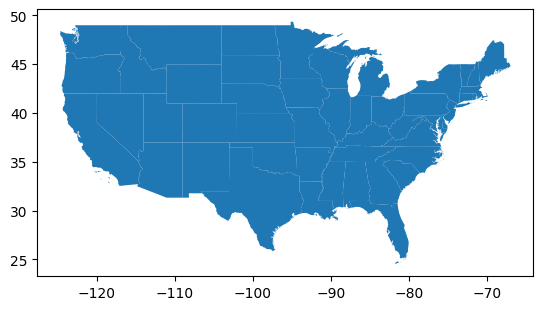

In [8]:
contiguous_states.plot()

In [10]:
df.FAC_STATE.unique()

array(['DC', 'DE', 'CA', 'AL', 'FL', 'NC', 'WA', 'AK', 'IA', 'SC', 'LA',
       'TN', 'OK', 'NY', 'KS', 'MS', 'MA', 'CO', 'KY', 'NJ', 'TX', 'RI',
       'AZ', 'IL', 'IN', 'NM', 'OH', 'WY', 'MD', 'VA', 'WV', 'MI', 'AR',
       'MO', 'MN', 'PA', 'PR', 'NH', 'ND', 'GA', 'NE', 'GE', 'UT', 'WI',
       'CT', 'ID', 'MT', 'BC', 'NV', 'OR', 'VT', 'HI', 'ME', 'SD', 'GU',
       nan, 'AS', 'VI', 'MP', 'DM', 'GM', 'UM', 'CN', 'MH', 'ON', 'MB',
       'QC', 'NB', 'AB', 'SK', 'AA', 'PW', 'AP', 'TT', 'JA', 'FM', 'CS',
       'SN', 'CY', 'MW', 'GB', 'XX', 'XF', 'CZ', 'NN', 'FR', 'XI', 'XH',
       'UK'], dtype=object)

In [12]:
# Define non-contiguous state abbreviations
non_contiguous = ['AK', 'HI', 'PR', 'GU', 'AS', 'VI', 'MP']

# Filter for facilities with valid coordinates, in contiguous states, and within map bounds
valid_coords = df[
    df['LATITUDE_MEASURE'].notna() & 
    df['LONGITUDE_MEASURE'].notna() &
    (df['LATITUDE_MEASURE'] != 0) & 
    (df['LONGITUDE_MEASURE'] != 0) &
    (~df['FAC_STATE'].isin(non_contiguous)) 
]

In [14]:
# Create GeoDataFrame from coordinates
gdf = gpd.GeoDataFrame(
    valid_coords,
    geometry=gpd.points_from_xy(
        valid_coords['LONGITUDE_MEASURE'],
        valid_coords['LATITUDE_MEASURE']
    ),
    crs="EPSG:4326"
)

In [21]:
states_union = contiguous_states.geometry.unary_union

/tmp/ipykernel_443895/1819584551.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  states_union = contiguous_states.geometry.unary_union


In [24]:
gdf

,FAC_NAME,FAC_STREET,FAC_CITY,FAC_STATE,FAC_ZIP,REGISTRY_ID,FAC_COUNTY,FAC_EPA_REGION,LATITUDE_MEASURE,LONGITUDE_MEASURE,geometry
0,U.S. DOJ BUREAU OF ALCOHOL TOBACCO FIREARMS & ...,650 MASSACHUSETTS AVE NW,WASHINGTON,DC,20001,110002498707,DISTRICT OF COLUMBIA,3.0,38.901940,-77.021270,POINT (-77.02127 38.90194)
1,US CUSTOMS RESEARCH BRANCH,1301 CONSTITUTION AVE NW,WASHINGTON,DC,20229,110002498725,DISTRICT OF COLUMBIA,3.0,38.892090,-77.030350,POINT (-77.03035 38.89209)
2,VERIZON GARAGE GLC-12307,980 V STREET NE,WASHINGTON,DC,20018,110002498752,DISTRICT OF COLUMBIA,3.0,38.917480,-76.991130,POINT (-76.99113 38.91748)
3,CARNEGIE INSTITUTE,2801 UPTON STREET NW,WASHINGTON,DC,20008,110002498789,DISTRICT OF COLUMBIA,3.0,38.942690,-77.055690,POINT (-77.05569 38.94269)
4,CAPITOL HILL GARAGE LLC,645 MARYLAND AVENUE NE,WASHINGTON,DC,20002,110002502131,DISTRICT OF COLUMBIA,3.0,38.894500,-76.997240,POINT (-76.99724 38.8945)
...,...,...,...,...,...,...,...,...,...,...,...
3037819,ELITE LINEMEN TRAINING FACILITY,1200 BANDY LANE,RINGGOLD,GA,30736,110071926714,NaN,4.0,34.872651,-85.082366,POINT (-85.08237 34.87265)
3037820,LIBERTY CHRISTIAN GYMNASIUM FACILITY,211 KINSTON HIGHWAY,RICHLANDS,NC,28574,110071926715,NaN,4.0,34.906930,-77.561960,POINT (-77.56196 34.90693)
3037821,WIRE ROAD WATER LINE EXTENSION,WIRE ROAD AT GUN RANGE ROAD,NaN,SC,29801,110071926716,AIKEN,4.0,33.596667,-81.675000,POINT (-81.675 33.59667)
3037822,CHARLOTTE MOTOR SPEEDWAY ROAD COURSE,MOREHEAD ROAD,CONCORD/HARRISBURG,NC,28027,110071926948,NaN,4.0,35.346500,-80.687400,POINT (-80.6874 35.3465)
